In [3]:
import anndata as ad
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import scanpy as sc
import seaborn as sns
import sys
from collections import defaultdict
from natsort import natsorted

In [1]:
def plot_knee(adata, category_column='sublibrary'):
    unique_categories = natsorted(adata.obs[category_column].unique())
    color_palette = sns.color_palette("husl", n_colors=len(unique_categories))

    fig, ax = plt.subplots(figsize=(10, 7))

    for category, color in zip(unique_categories, color_palette):
        # subset the data for each sublibrary
        subset = adata[adata.obs[category_column] == category]

        # calculate knee and num_cells for the subset
        knee = np.sort((np.array(subset.layers['raw_counts'].sum(axis=1))).flatten())[::-1]
        cell_set = np.arange(len(knee))
        num_cells = cell_set[::-1][0]

        # plot the knee for the current sublibrary
        ax.loglog(cell_set, knee, linewidth=5, color=color, label=f"{category} - {num_cells} cells")

    ax.axhline(y=500, linewidth=3, color="k", linestyle='--')

    ax.set_ylabel("UMI Counts",fontsize=18)
    ax.set_xlabel("Set of Barcodes",fontsize=18)
    ax.legend(fontsize=14, bbox_to_anchor=(1.05, 1), loc='upper left')

    ax.tick_params(axis='both', which='major', labelsize=16)

    plt.grid(True, which="both")

In [4]:
adata = sc.read_10x_mtx("/Users/emattei/Tmp/scanpy/", prefix=None)
adata

AnnData object with n_obs × n_vars = 7077888 × 56953
    var: 'gene_ids', 'feature_types'

In [5]:
adata.var['gene_name'] = adata.var.index

In [6]:
adata.obs['barcode'] = adata.obs.index

In [7]:
adata.var['mt'] = adata.var['gene_name'].str.startswith('mt-')
sc.pp.calculate_qc_metrics(adata, qc_vars=['mt'], percent_top=None, log1p=False, inplace=True)

In [ ]:
adata.layers['raw_counts'] = adata.X.copy()
adata.obs['sublibrary'] = "sample"
adata.write_h5ad('/Users/emattei/Tmp/scanpy/.h5ad')

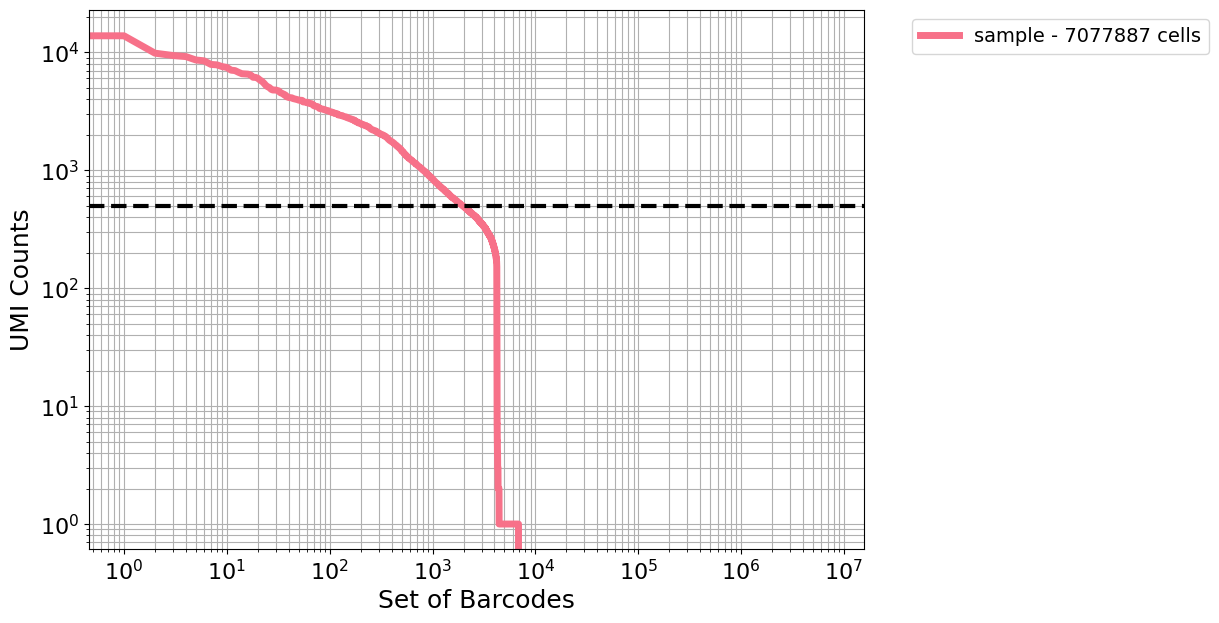

In [11]:
plot_knee(adata, category_column='sublibrary')
plt.show()

/Users/emattei/GitHub/epi-SHARE-seq-pipeline/.venv/lib/python3.10/site-packages/scanpy/plotting/_anndata.py:900: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(
/Users/emattei/GitHub/epi-SHARE-seq-pipeline/.venv/lib/python3.10/site-packages/scanpy/plotting/_anndata.py:900: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(
/Users/emattei/GitHub/epi-SHARE-seq-pipeline/.venv/lib/python3.10/site-packages/scanpy/plotting/_anndata.py:900: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(


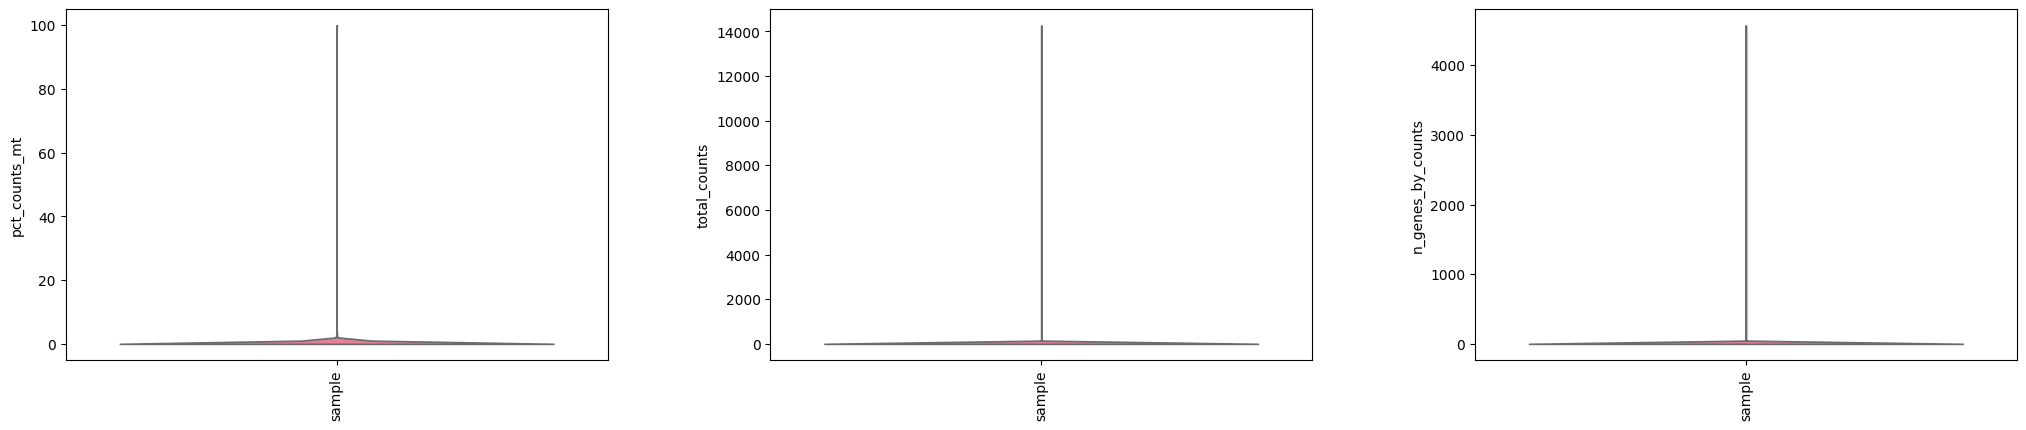

In [14]:
color_palette = sns.color_palette("husl", n_colors=len(adata.obs['sublibrary'].unique()))

sc.pl.violin(adata, ['pct_counts_mt', 'total_counts', 'n_genes_by_counts'],
             groupby = "sublibrary", palette = color_palette, rotation = 90,
             jitter=0.4, multi_panel=True, size=0)

In [15]:
sc.pp.filter_cells(adata, min_counts = 500) # UMI cutoff
sc.pp.filter_cells(adata, max_counts = 100000)
sc.pp.filter_cells(adata, min_genes = 250) # min number of genes per cell
adata = adata[adata.obs.pct_counts_mt < 1, :]

/Users/emattei/GitHub/epi-SHARE-seq-pipeline/.venv/lib/python3.10/site-packages/scanpy/plotting/_anndata.py:900: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(
/Users/emattei/GitHub/epi-SHARE-seq-pipeline/.venv/lib/python3.10/site-packages/scanpy/plotting/_anndata.py:900: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(
/Users/emattei/GitHub/epi-SHARE-seq-pipeline/.venv/lib/python3.10/site-packages/scanpy/plotting/_anndata.py:900: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(


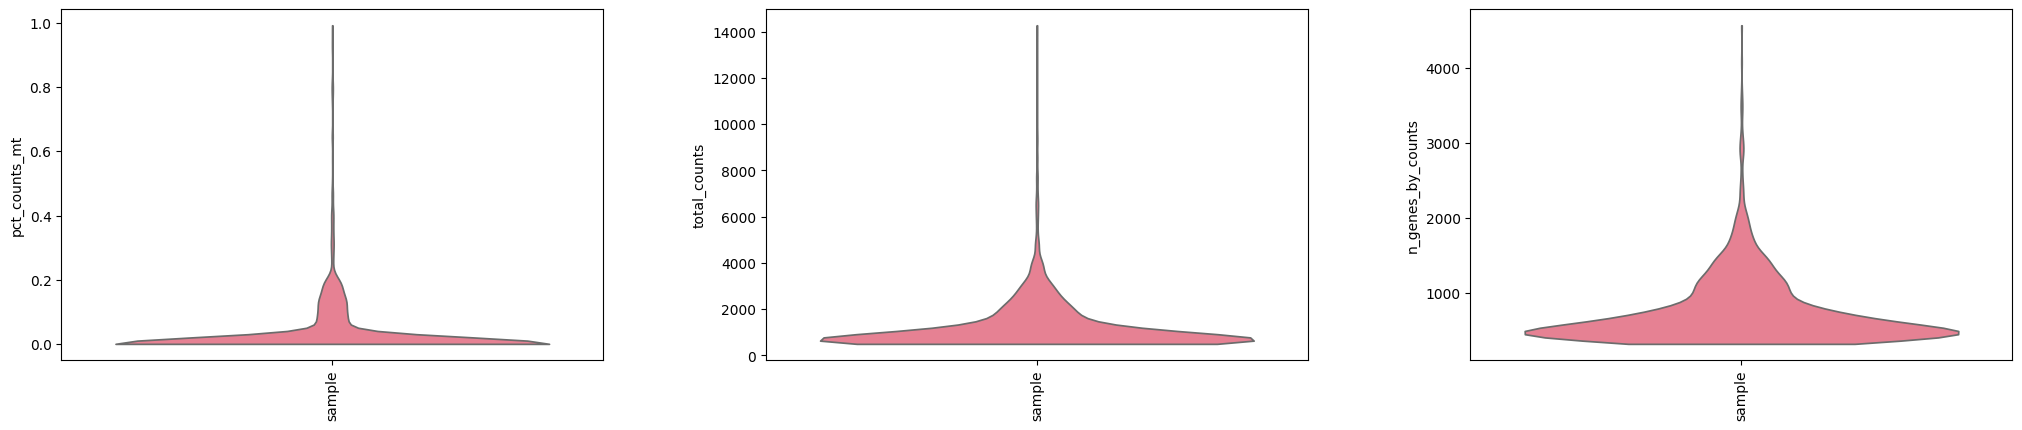

In [17]:
sc.pl.violin(adata, ['pct_counts_mt', 'total_counts', 'n_genes_by_counts'],
             groupby = "sublibrary", palette = color_palette, rotation = 90,
             jitter=0.4, multi_panel=True, size=0)

In [18]:
### normalize the data ###
sc.pp.normalize_total(adata, target_sum=1e4) # Counts per 10k
#adata.layers['norm_10k'] = adata.X
sc.pp.log1p(adata)
#adata.layers['norm_log1p'] = adata.X

### calculate highly variable genes ###
# highly variable genes are used to compute the clustering 
sc.pp.highly_variable_genes(adata, min_mean=0.0125, max_mean=3, min_disp=0.5)

/Users/emattei/GitHub/epi-SHARE-seq-pipeline/.venv/lib/python3.10/site-packages/scanpy/preprocessing/_normalization.py:207: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


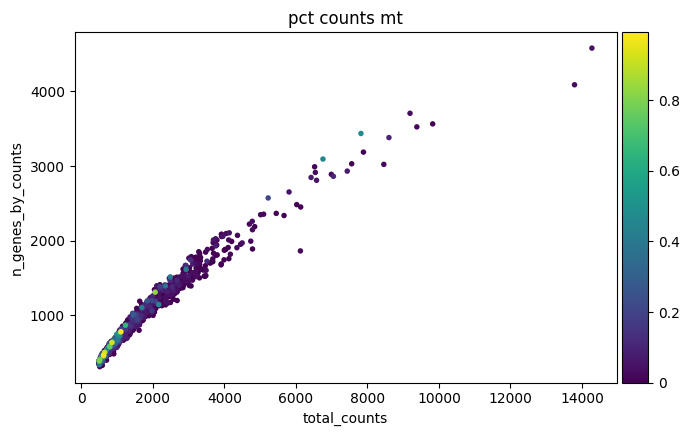

In [25]:
sc.pl.scatter(adata, "total_counts", "n_genes_by_counts", color="pct_counts_mt")

In [19]:
adata_p = adata[:, adata.var.highly_variable]
sc.tl.pca(adata_p, svd_solver='arpack', use_highly_variable = True)
sc.pp.neighbors(adata_p, n_neighbors=20, n_pcs=30)
sc.tl.leiden(adata_p, resolution = 1)
sc.tl.umap(adata_p, min_dist = 0.5, spread =2.0)

/Users/emattei/GitHub/epi-SHARE-seq-pipeline/.venv/lib/python3.10/site-packages/scanpy/preprocessing/_pca.py:377: FutureWarning: Argument `use_highly_variable` is deprecated, consider using the mask argument. Use_highly_variable=True can be called through mask_var="highly_variable". Use_highly_variable=False can be called through mask_var=None
  warn(msg, FutureWarning)
/Users/emattei/GitHub/epi-SHARE-seq-pipeline/.venv/lib/python3.10/site-packages/scanpy/preprocessing/_pca.py:317: ImplicitModificationWarning: Setting element `.obsm['X_pca']` of view, initializing view as actual.
  adata.obsm[key_obsm] = X_pca
/Users/emattei/GitHub/epi-SHARE-seq-pipeline/.venv/lib/python3.10/site-packages/threadpoolctl.py:1214: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes o

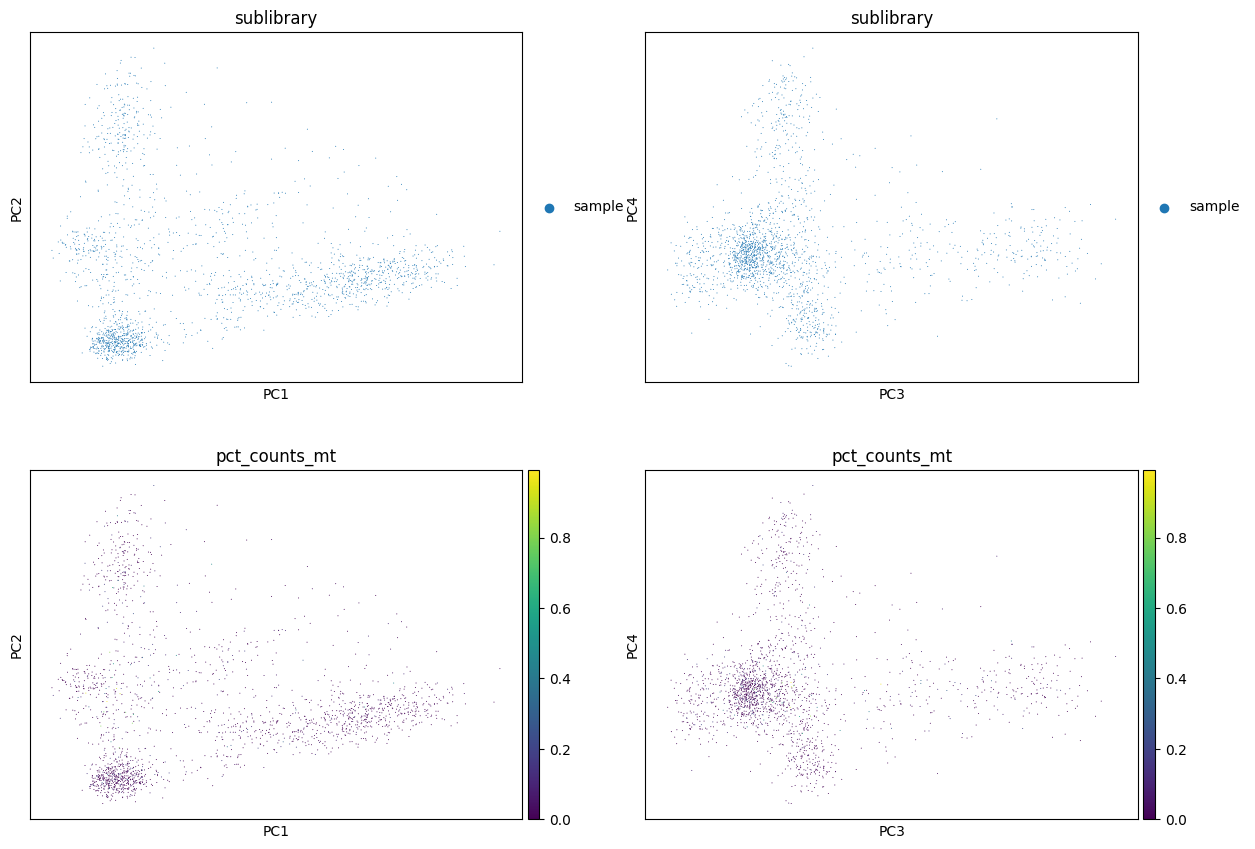

In [29]:
sc.pl.pca(
    adata_p,
    color=["sublibrary", "sublibrary", "pct_counts_mt", "pct_counts_mt"],
    dimensions=[(0, 1), (2, 3), (0, 1), (2, 3)],
    ncols=2,
    size=2,
)

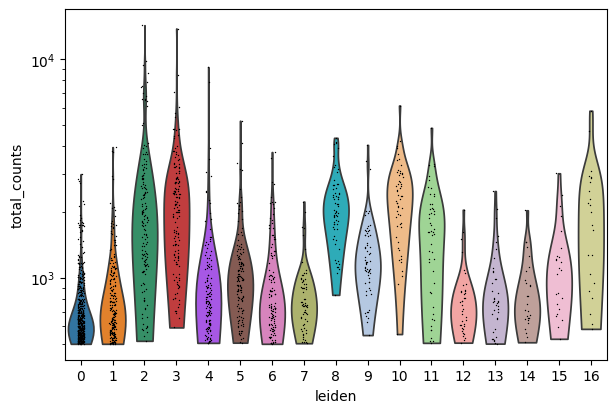

In [20]:
sc.pl.violin(adata_p, 'total_counts', groupby = 'leiden', log = True)

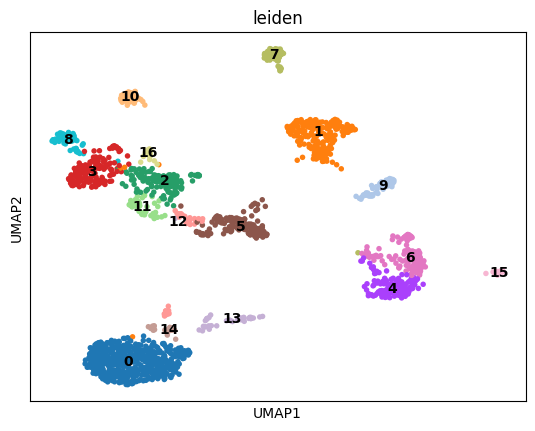

In [22]:
sc.pl.umap(adata_p, color = 'leiden', legend_loc = 'on data')

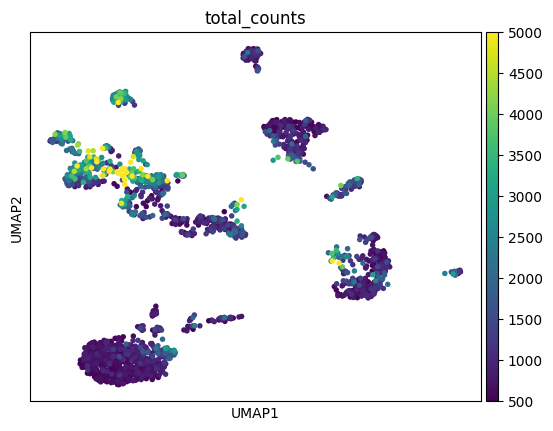

In [23]:
sc.pl.umap(adata_p, color = ['total_counts'], vmax = 5000)

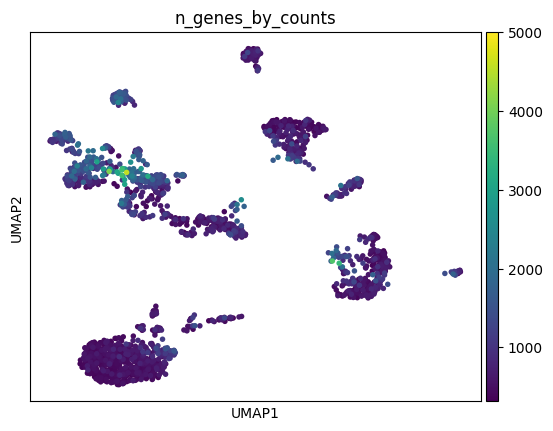

In [24]:
sc.pl.umap(adata_p, color = ['n_genes_by_counts'], vmax = 5000)


In [38]:
adata.layers['raw_counts'].sum()

2428709.0